In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-17 16:51:28.831552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773766289.275466      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773766289.379250      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773766290.596991      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773766290.597024      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773766290.597027      55 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
data_dir = "/kaggle/input/datasets/ahmedhamada0/brain-tumor-detection"

In [4]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [5]:
train_data = datagen.flow_from_directory(
    data_dir,
    classes=['no','yes'],
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    classes=['no','yes'],
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


In [6]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773766338.713186      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773766338.719394      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,113 (37.48 MB)

 Trainable params: 9,826,113 (37.48 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1773766347.940516     134 service.cc:152] XLA service 0x796898002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773766347.940554     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773766347.940558     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773766348.502978     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-17 16:52:32.098795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 16:52:32.248768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/75 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.3672 - loss: 0.7313  

I0000 00:00:1773766355.575661     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 63s 713ms/step - accuracy: 0.6604 - loss: 0.5984 - val_accuracy: 0.7967 - val_loss: 0.4588
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 473ms/step - accuracy: 0.8271 - loss: 0.4133 - val_accuracy: 0.8267 - val_loss: 0.4041
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 468ms/step - accuracy: 0.8429 - loss: 0.3511 - val_accuracy: 0.8150 - val_loss: 0.4617
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 477ms/step - accuracy: 0.8677 - loss: 0.3312 - val_accuracy: 0.8600 - val_loss: 0.3553
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 469ms/step - accuracy: 0.8670 - loss: 0.2983 - val_accuracy: 0.8983 - val_loss: 0.2993
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 466ms/step - accuracy: 0.9036 - loss: 0.2412 - val_accuracy: 0.9150 - val_loss: 0.2193
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 464ms/step - accuracy: 0.9228 - loss: 0.2034 - val_accuracy: 0.9467 - val_loss: 0.1466
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 466ms/step - accuracy: 0.9437 - loss: 0.1551 - val_accuracy: 0.965

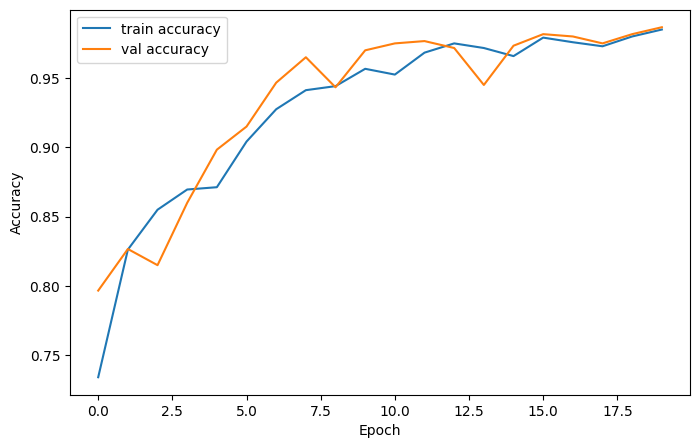

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='val accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [10]:
def predict_image(path):

    img = cv2.imread(path)
    img = cv2.resize(img,(224,224))
    img = img/255.0
    img = np.expand_dims(img,axis=0)

    pred = model.predict(img)

    if pred > 0.5:
        print("Tumor Detected")
    else:
        print("No Tumor")

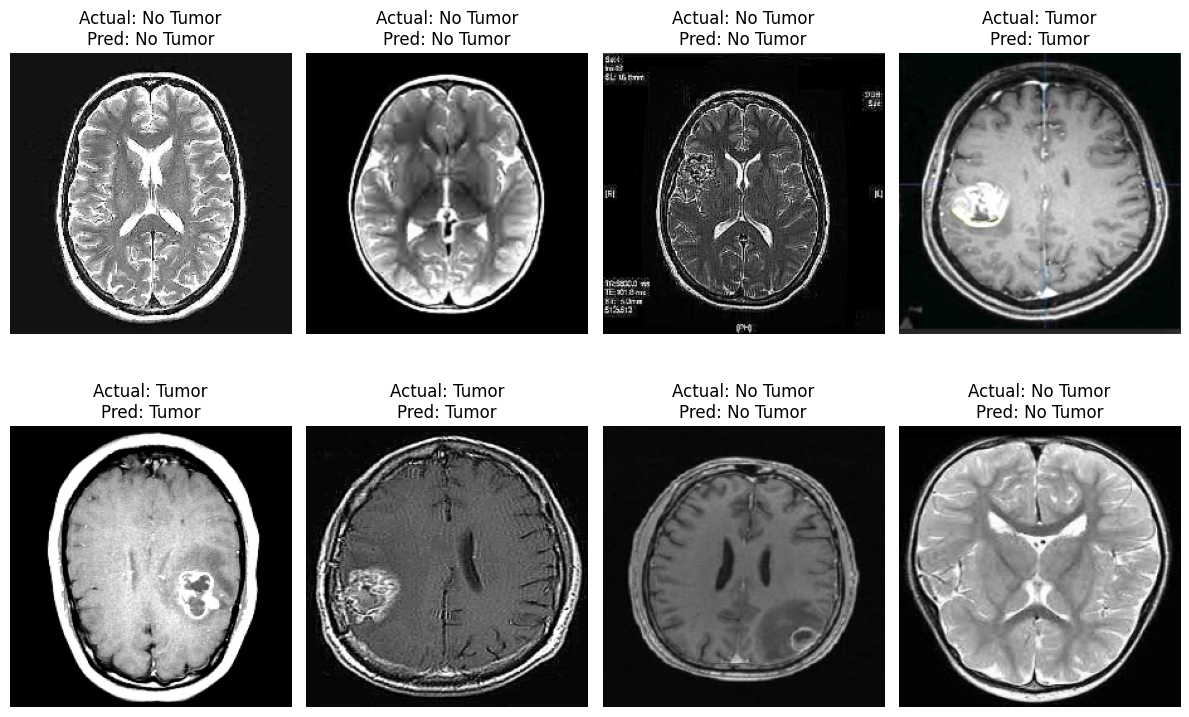

In [29]:
import random
num_images = 8

# class folders
classes = ["no", "yes"]

image_paths = []

# collect image paths
for c in classes:
    folder = os.path.join(data_dir, c)
    imgs = os.listdir(folder)
    
    for img in imgs:
        image_paths.append((os.path.join(folder, img), c))

# randomly pick images
sample_images = random.sample(image_paths, num_images)

plt.figure(figsize=(12,8))

for i,(path,label) in enumerate(sample_images):

    img = cv2.imread(path)
    img = cv2.resize(img,(224,224))
    
    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # preprocess
    img = img/255.0
    img = np.expand_dims(img,axis=0)

    pred = model.predict(img, verbose=0)

    pred_label = "Tumor" if pred>0.5 else "No Tumor"
    actual_label = "Tumor" if label=="yes" else "No Tumor"

    plt.subplot(2,4,i+1)
    plt.imshow(display_img)
    plt.title(f"Actual: {actual_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

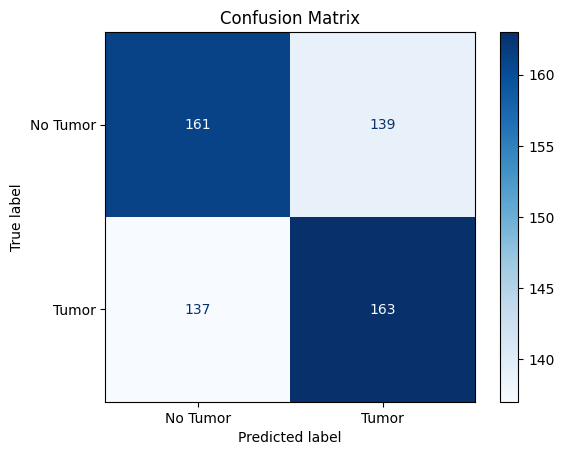

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor","Tumor"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Tumor","Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       0.54      0.54      0.54       300
       Tumor       0.54      0.54      0.54       300

    accuracy                           0.54       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.54      0.54      0.54       600



19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step


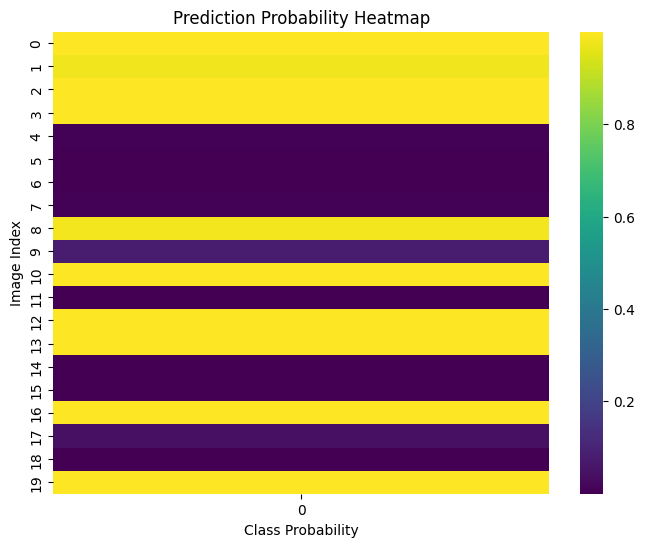

In [32]:
import seaborn as sns

pred_probs = model.predict(val_data)

plt.figure(figsize=(8,6))
sns.heatmap(pred_probs[:20],
            cmap="viridis",
            cbar=True)

plt.title("Prediction Probability Heatmap")
plt.xlabel("Class Probability")
plt.ylabel("Image Index")
plt.show()

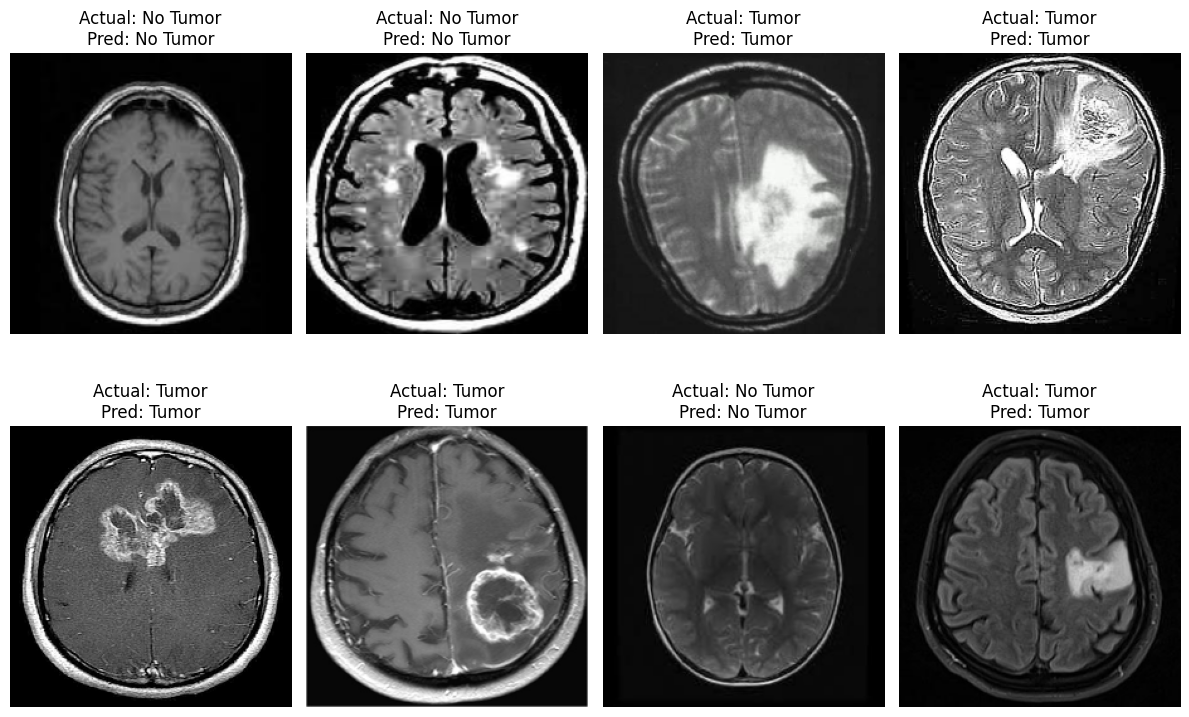

In [33]:
import random
import cv2
import os

num_images = 8
classes = ["no","yes"]

image_paths = []

for c in classes:
    folder = os.path.join(data_dir, c)
    imgs = os.listdir(folder)

    for img in imgs:
        image_paths.append((os.path.join(folder,img), c))

sample_images = random.sample(image_paths, num_images)

plt.figure(figsize=(12,8))

for i,(path,label) in enumerate(sample_images):

    img = cv2.imread(path)
    img = cv2.resize(img,(224,224))
    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img/255.0
    img = np.expand_dims(img,axis=0)

    pred = model.predict(img, verbose=0)

    pred_label = "Tumor" if pred>0.5 else "No Tumor"
    actual_label = "Tumor" if label=="yes" else "No Tumor"

    plt.subplot(2,4,i+1)
    plt.imshow(display_img)
    plt.title(f"Actual: {actual_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

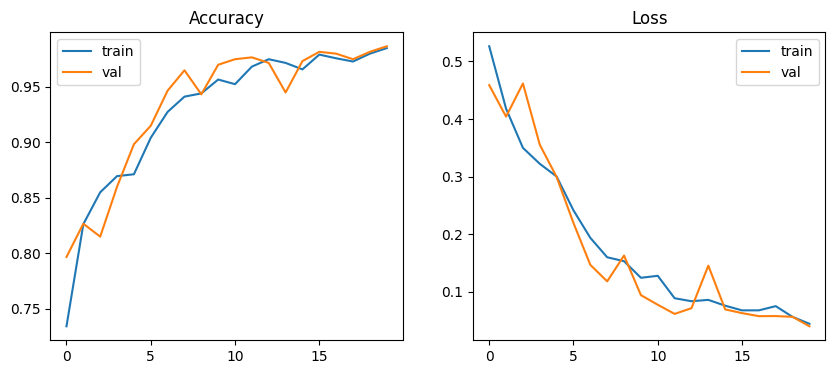

In [34]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.show()